# Table of Contents
<span style="font-size:16px;">
    
**1.** Data Description <br>
**2.** Data Loading <br>
**3.** Data Preprocessing <br>
**4.** Exploratory Data Analysis (EDA)<br>
**5.** Feature Engineering <br>
**6.** Model Selection <br>
**7.** Model Evaluation <br>
**8.** Sanity Check <br>
**9.** Conclusion <br>
**10.** Summary <br>

</span>

# Task Description
# Rusty Bargain Used Car Sales
<span style="font-size:16px;"> `Rusty Bargain` is developing an app to attract new customers, and they need to be able to quickly find out the market value of a car. We are given access to historical data: technical specifications, trim, and prices. `Rusty Bargain` wants a model that will predict the value of the car, while also considering the <b>quality</b> and <b>speed</b> of the prediction, and also the <b>time</b> required for training.
</span>

# Data Description
### Feature Columns:

<span style="font-size:16px;">
    
`DateCrawled` — date the profile was downloaded from the database  
`VehicleType` — vehicle body type  
`RegistrationYear` — vehicle registration year  
`Gearbox` — gearbox type  
`Power` — engine power (hp)  
`Model` — vehicle model  
`Mileage` — vehicle mileage (km)  
`RegistrationMonth` — vehicle registration month  
`FuelType` — fuel type  
`Brand` — vehicle brand  
`NotRepaired` — whether the vehicle has been repaired or not  
`DateCreated` — date when the profile was created  
`NumberOfPictures` — number of vehicle pictures  
`PostalCode` — postal code of the profile owner  
`LastSeen` — date of the user's last activity
</span>

### Target Variable:
<span style="font-size:16px;">

`Price` — vehicle price (Euro)
</span>


# Imports

In [178]:
#!pip install catboost lightgbm xgboost -U

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  # nice background for charts
import re
import time

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse

import sys
import warnings
if not sys.warnoptions:
       warnings.simplefilter("ignore")

pd.set_option('display.max_rows', None, 'display.max_columns', None)

print("Setup Complete!")

Setup Complete!


# Data Load

In [218]:
try:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/car_data.csv')
    
except:
    df = pd.read_csv('/datasets/car_data.csv')

In [219]:
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [221]:
df.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


<span style="font-size:16px;">
    
### Notes for Preprocessing:

The dataset contains over 354k car listings with **15 features** (6 categorical, 9 numerical) and **1 target variable**.<br> The main **preprocessing steps** are:

- Convert all column names to **lowercase** for consistency.
- Convert the three date-related columns to proper **datetime format**.  
- Filling **missing values** where necessary.  
- Check and remove **duplicate rows**.   
- **Standardize** `fuel_type` by changing *"petrol"* to *"gasoline"*.  
- Remove features that are not informative for `price` prediction:  
  - `DateCrawled` and `LastSeen`  
  - `NumberOfPictures` (all values are 0)  
- **Calculate the age** of each car (`car_age`) as the difference between `DateCreated` year and `RegistrationYear`.
- **Encode** the categorical features (required for some models). 
- Check numeric features for **outliers** and inconsistencies:  
  - `RegistrationYear`: 1000 - 9999 → likely outliers  
  - `Price`: Target distribution is positively skewed; → 0-value observations 
  - `Mileage`: check for extreme values  
  - `Power`: max value unusually high (outlier), min = 0 → not possible 
- The target variable is numeric, so this is a **Regression task**.
</span>

---

# Data Preprocessing

### Feature Name Standardization

In [222]:
df.columns = (
    df.columns
      .str.replace('(.)([A-Z][a-z]+)', r'\1_\2', regex=True)
      .str.replace('([a-z0-9])([A-Z])', r'\1_\2', regex=True)
      .str.lower()
)

In [223]:
df.head(3)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47


### Data Type Conversion

In [224]:
df['date_created'] = pd.to_datetime(df['date_created'])

# adding 'car_age' column
df['year_created'] = df['date_created'].dt.year
df['car_age'] = df['year_created'] - df['registration_year']

### Missing Values Handling

In [225]:
df.isnull().sum() / df.shape[0] * 100

date_crawled           0.000000
price                  0.000000
vehicle_type          10.579368
registration_year      0.000000
gearbox                5.596709
power                  0.000000
model                  5.560588
mileage                0.000000
registration_month     0.000000
fuel_type              9.282697
brand                  0.000000
not_repaired          20.079070
date_created           0.000000
number_of_pictures     0.000000
postal_code            0.000000
last_seen              0.000000
year_created           0.000000
car_age                0.000000
dtype: float64

<span style="font-size:16px;">
    
The dataset has missing values in 5 features. We will start with **`NotRepaired`**, which has the largest proportion of missing values - over **20%**.
Since more than 20% of the entries are missing, dropping these rows is not a good option. Instead, we will fill the missing values with **`'unknown'`** to indicate that the repair status is not available.

</span>

In [226]:
df['not_repaired'].fillna('unknown', inplace=True)
df['gearbox'].fillna('unknown', inplace=True)

### `fuel_type`

<span style="font-size:16px;">
    
There is no practical difference between `petrol` and `gasoline`; they are the same refined petroleum fuel used in spark-ignition engines, just with different regional names. "Gasoline" (or "gas") is primarily used in North America, while "petrol" is standard in the UK, Europe.
</span>	

In [227]:
df['fuel_type'] = df['fuel_type'].replace('petrol', 'gasoline')

### `model` & `vehichle_type`

<span style="font-size:16px;">
    
We drop rows where both **`VehicleType`** and **`Model`** are missing.  
From ML perspective, these two features are critical descriptors of the vehicle.  If both are missing, the data point provides very little information for predicting the target variable, so keeping it would add noise to the model. <br>
For all other categorical columns with missing data, we fill the missing entries with `'unknown'`. 

</span>

In [228]:
# dropping rows where vehicle type and model are missing
mask = (df['vehicle_type'].isnull() & df['model'].isnull())
df.drop(df[mask].index, inplace=True)

In [229]:
for col in ['model','vehicle_type','fuel_type']:
    df[col].fillna('unknown', inplace=True) 

In [230]:
#Remove non-informative features (timestamps, location codes, constant columns etc.) as they do not improve model performance.

df = df.drop(['postal_code','date_crawled','last_seen', 'number_of_pictures','date_created'], axis=1)

In [231]:
df.columns.to_list()

['price',
 'vehicle_type',
 'registration_year',
 'gearbox',
 'power',
 'model',
 'mileage',
 'registration_month',
 'fuel_type',
 'brand',
 'not_repaired',
 'year_created',
 'car_age']

### Duplicate Removal

In [232]:
int(df.duplicated().sum())

27005

In [233]:
df = df.drop_duplicates(ignore_index=True)

In [234]:
df.isna().sum()

price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
mileage               0
registration_month    0
fuel_type             0
brand                 0
not_repaired          0
year_created          0
car_age               0
dtype: int64

### Preprocessing Summary:
<span style="font-size:16px;">

During preprocessing, we **removed nearly 34k entries** due to missing critical information or duplicates.  
All remaining missing values in categorical features were filled with `'unknown'`.  

After cleaning, the dataset now **contains 320k valid entries**, ready for exploratory data analysis (`EDA`).  
This ensures the models will train on consistent, meaningful, and complete data.
</span>

---

# Exploratory Data Analysis (EDA)

## Handling Outliers

### `registration_year`

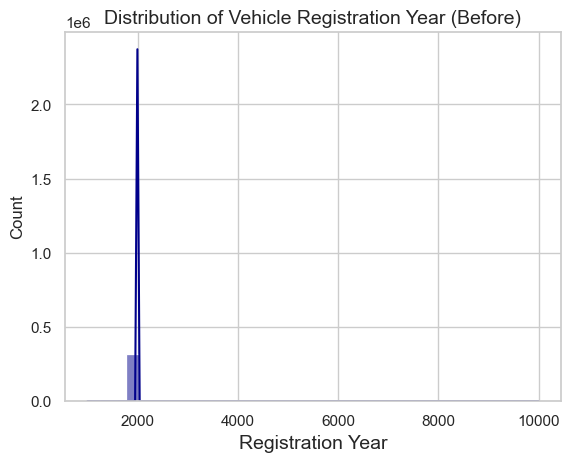

In [235]:
plt.figure()
sns.histplot(df['registration_year'], bins=35, kde=True, color='darkblue')
plt.title('Distribution of Vehicle Registration Year (Before)', fontsize=14)
plt.xlabel('Registration Year', fontsize=14)
plt.show()

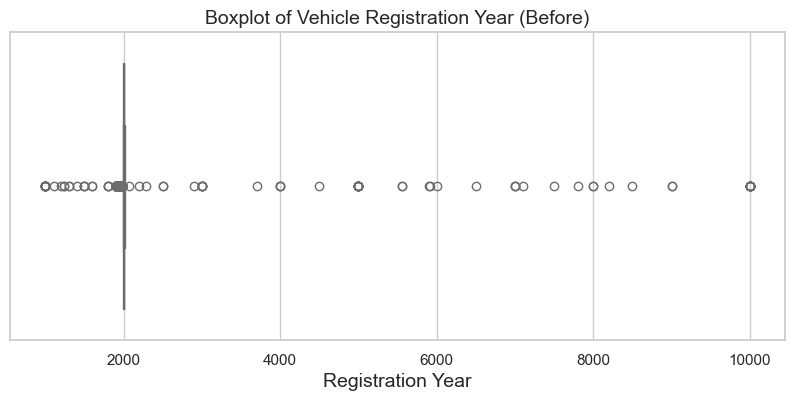

In [236]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['registration_year'], color='salmon')
plt.title('Boxplot of Vehicle Registration Year (Before)', fontsize=14)
plt.xlabel('Registration Year', fontsize=14)
plt.show()

In [237]:
# filtering outliers of dataset
df = df.query("(registration_year >= 1950) and (registration_year <= 2019)")

### Handling Outliers in `registration_year`

<span style="font-size:16px;">
 
The first car in Europe was made in 1897, but it is **highly unlikely** that such early vehicles would appear on the `Rusty Bargain` app. Similarly, cars registered **before 1950** are rare in the dataset, so removing them will not significantly reduce data.  
On the other end, registration years **above 2019** are clearly invalid (Since data is extracted in 2016, there shouldn't be any `registration_year` more than that), as they represent vehicles registered in the future.  
</span>

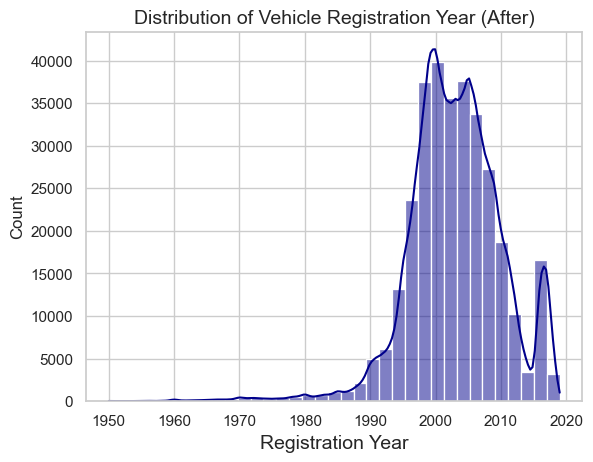

In [238]:
plt.figure()
sns.histplot(df['registration_year'], bins=35, kde=True, color='darkblue')
plt.title('Distribution of Vehicle Registration Year (After)', fontsize=14)
plt.xlabel('Registration Year', fontsize=14)
plt.show()

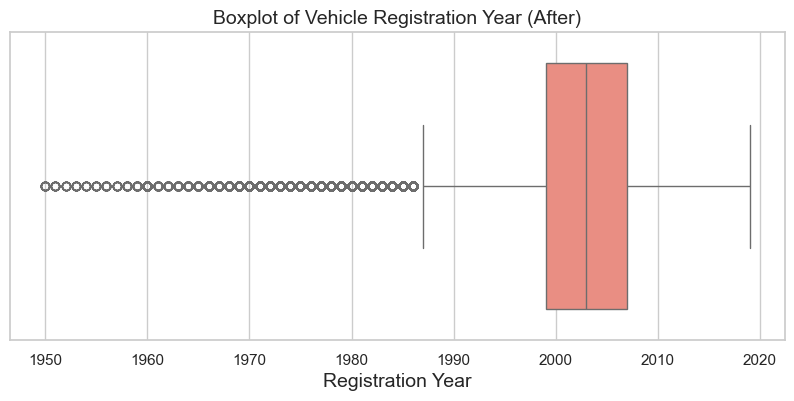

In [239]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['registration_year'], color='salmon')
plt.title('Boxplot of Vehicle Registration Year (After)', fontsize=14)
plt.xlabel('Registration Year', fontsize=14)
plt.show()

### `power` (hp)

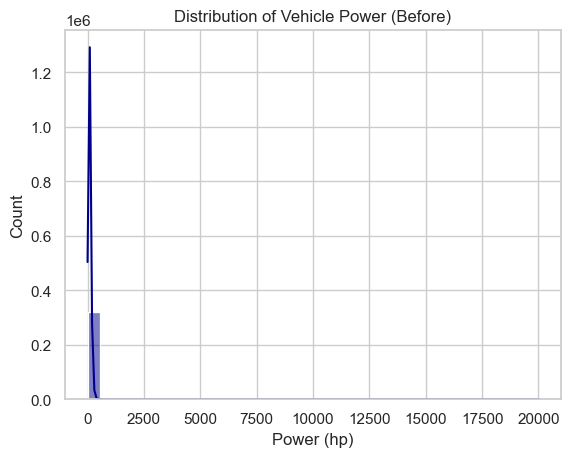

In [240]:
plt.figure()
sns.histplot(df['power'], bins=35,kde=True, color='darkblue')
plt.title('Distribution of Vehicle Power (Before)')
plt.xlabel('Power (hp)')
plt.ylabel('Count')
plt.show()

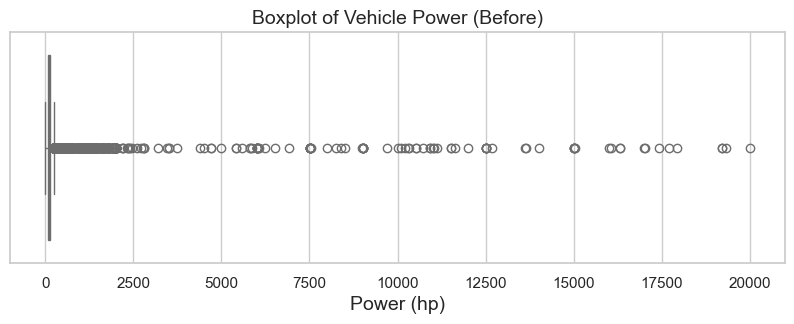

In [241]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['power'], color='salmon')
plt.title('Boxplot of Vehicle Power (Before)', fontsize=14)
plt.xlabel('Power (hp)', fontsize=14)
plt.show()

### Handling Outliers in `vehicle_power`
<span style="font-size:16px;">
    
- Vehicles with `Power = 0` do not make sense, as all cars, including electric vehicles, have some engine power.  
- Extremely high power values (above 500 hp) are uncommon and typically belong to supercars or hypercars, which are **not representative** of most vehicles in our dataset.  
By removing these **outliers**, we focus the model on **realistic** vehicle power ranges, improving its ability to learn meaningful patterns.
</span>

In [242]:
df = df.query("(power > 20) and (power < 500)")

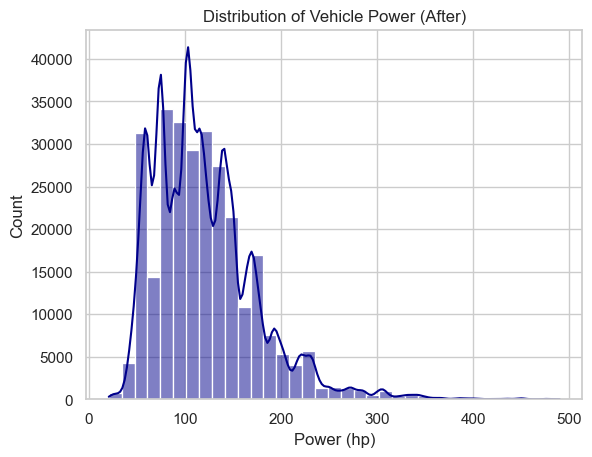

In [243]:
plt.figure()
sns.histplot(df['power'], bins=35, kde=True, color='darkblue')
plt.title('Distribution of Vehicle Power (After)')
plt.xlabel('Power (hp)')
plt.ylabel('Count')
plt.show()

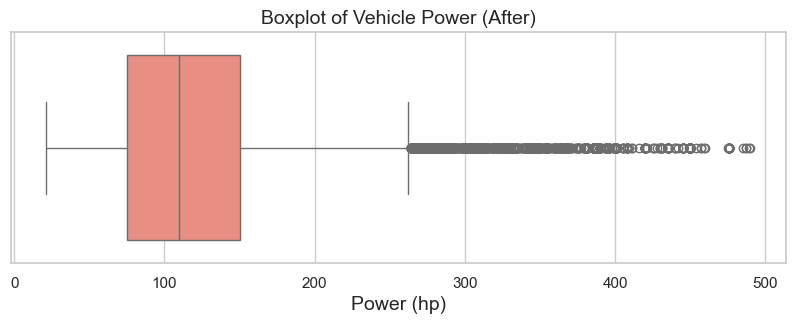

In [244]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['power'], color='salmon')
plt.title('Boxplot of Vehicle Power (After)', fontsize=14)
plt.xlabel('Power (hp)', fontsize=14)
plt.show()

### `price` (euro)

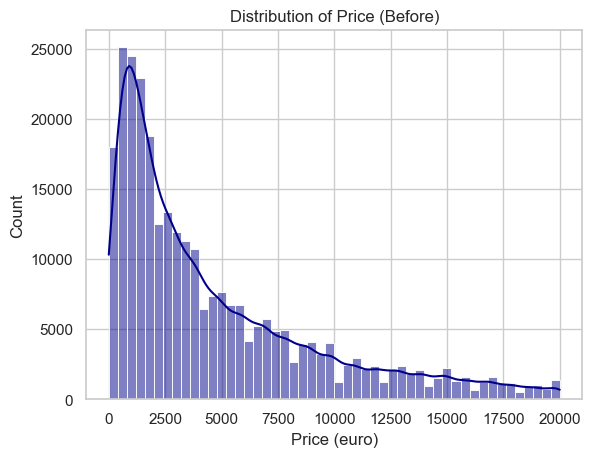

In [245]:
plt.figure()
sns.histplot(df['price'], bins=50, kde=True, color='darkblue')
plt.title('Distribution of Price (Before)')
plt.xlabel('Price (euro)')
plt.ylabel('Count')
plt.show()

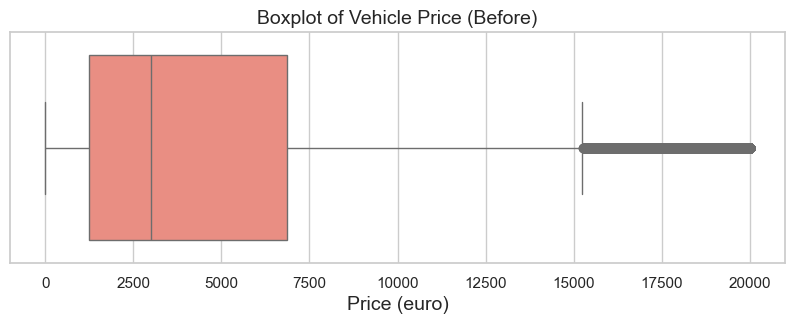

In [246]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['price'], color='salmon')
plt.title('Boxplot of Vehicle Price (Before)', fontsize=14)
plt.xlabel('Price (euro)', fontsize=14)
plt.show()

### Handling Outliers in `price`

<span style="font-size:16px;">

`Price` column contains some **unusual** values that need attention:
- **Zero prices:** Entries with a price of 0 are **unrealistic**, as every car has some monetary value. These could be due to **data entry errors** or missing listings that were improperly recorded.  
- **Extremely high prices:** Very expensive vehicles (prices above the `95th percentile`) may represent **rare, high-end cars**. While these values are valid, they are not representative of the typical car in the dataset and can skew the model.

To create a more robust model, we remove outliers by keeping the `5th to 95th percentile` of prices. Additionally, a specific suspicious entry with `Price = 12345` is removed as it appears to be an obvious **placeholder or error**.
This ensures that the dataset reflects **realistic** market prices, which helps improve model performance.
</span>

In [247]:
stats = df['price'].describe(percentiles=[0.025, 0.05, 0.95, 0.975])
print(stats)

count    285676.000000
mean       4705.723239
std        4596.363142
min           0.000000
2.5%        100.000000
5%          300.000000
50%        2999.000000
95%       14990.000000
97.5%     16999.000000
max       20000.000000
Name: price, dtype: float64


In [248]:
low, high = df["price"].quantile([0.05, 0.95])
df = df.query("price > @low and price < @high")

In [249]:
df = df.query("price != 12345")

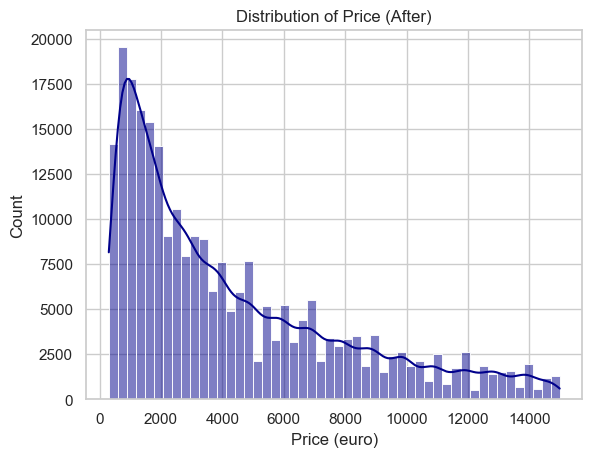

In [250]:
plt.figure()
sns.histplot(df['price'], bins=50, kde=True, color='darkblue')
plt.title('Distribution of Price (After)')
plt.xlabel('Price (euro)')
plt.ylabel('Count')
plt.show()

### Log Transformation of `price`

<span style="font-size:16px;">

The `price` variable is **positively skewed**, with many low-priced cars and a few very expensive vehicles. This skewness can make it difficult for regression models to learn effectively.  
To address this, we apply a `logarithmic transformation` to the `price` column (`price_log = log(price)`). <br>  
**Benefits of this transformation:**  
- Reduces **skewness** and spreads out lower values.  
- Helps the model focus on **relative differences** instead of extreme raw values.  
- Improves the stability and performance of regression models.  
- After the transformation, the distribution of `price_log` appears much closer to **normal**, which is preferable for many regression algorithms.

> **Note:** After predictions, we will **exponentiate (`exp`) the predicted log prices** to convert them back to the original price scale for interpretation and evaluation.
</span>	

In [251]:
df['price_log'] = np.log1p(df['price'])

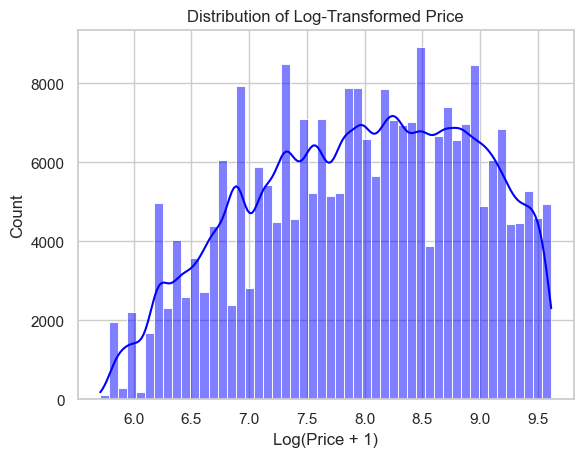

In [252]:
plt.figure()
sns.histplot(df['price_log'], bins=50, kde=True, color='blue')
plt.title('Distribution of Log-Transformed Price')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Count')
plt.show()

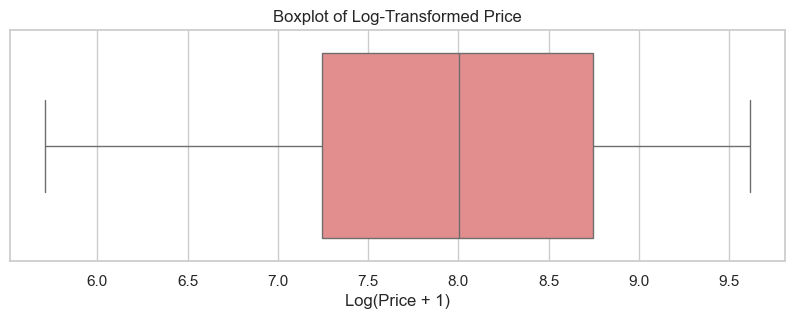

In [253]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['price_log'], color='lightcoral')
plt.title('Boxplot of Log-Transformed Price')
plt.xlabel('Log(Price + 1)')
plt.show()

### `mileage` (km)

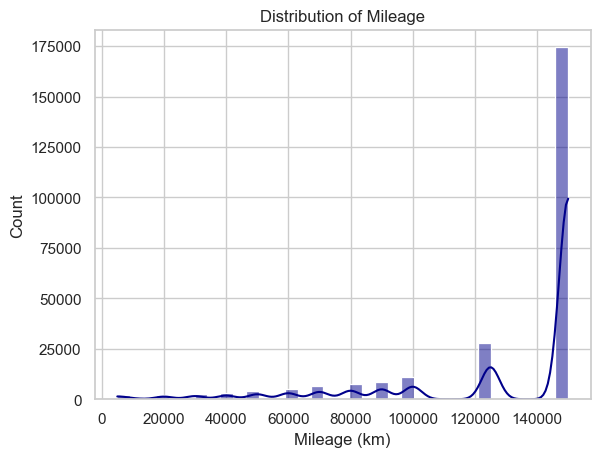

In [254]:
plt.figure()
sns.histplot(df['mileage'], bins=35, kde=True, color='darkblue')
plt.title('Distribution of Mileage')
plt.xlabel('Mileage (km)')
plt.ylabel('Count')
plt.show()

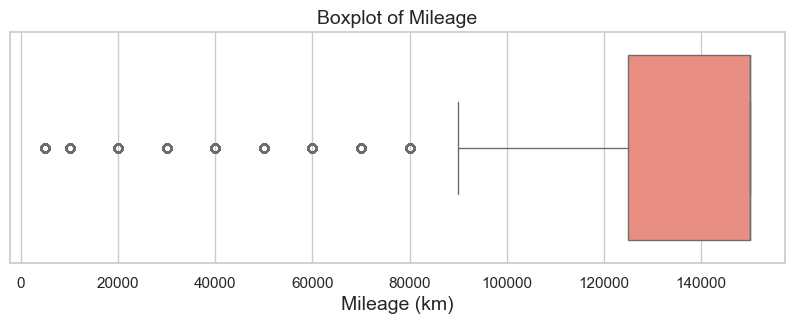

In [255]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['mileage'], color='salmon')
plt.title('Boxplot of Mileage', fontsize=14)
plt.xlabel('Mileage (km)', fontsize=14)
plt.show()

### `mileage` Feature Analysis:
<span style="font-size:16px;">

The `mileage` feature does not show traditional outliers but instead appears to be **capped at 150,000 km**, with a large number of observations at this value. This suggests that 150,000 may represent either a maximum recorded value or a grouped category (e.g., “150k+ km”). Therefore, **no outlier removal** is applied.
To help the model capture this behavior, a separate feature can be created to indicate high-mileage vehicles.
</span>


# Model Preparation

### Model Preparation:

<span style="font-size:16px;">	

After completing exploratory data analysis (`EDA`) and preprocessing, the dataset is now ready for modeling. The following steps will be applied to prepare the data for ML algorithms:

- **Encoding categorical features:**  
  Categorical variables will be transformed using `one-hot encoding` (`pd.get_dummies`) to convert them into a numerical format required by most models.

- **Feature selection:**  
  The original `price` column is removed from the feature set to prevent **data leakage**, since it directly represents the target variable. The model is trained using the transformed target (`price_log`) instead.

- **Splitting the data:**  
  The dataset is divided into **training, validation, and test sets** using a **60 / 20 / 20 split**:  
  - **60% Training set** – used to train the models  
  - **20% Validation set** – used for hyperparameter tuning and model selection  
  - **20% Test set** – used for final evaluation   

- **Feature scaling:**  
  Numerical features will be standardized using `StandardScaler` to ensure that all features are on a similar scale. This is particularly important for models sensitive to feature magnitude (e.g., `Linear Regression`).

These steps ensure that the data is properly structured, avoids data leakage, and allows for fair comparison between different models.

> **Note:** Tree-based models (`Decision Tree`, `Random Forest`, `Gradient Boosting` models such as `XGBoost`, `LightGBM`, and `CatBoost`) **don't require** feature scaling. However, scaling is applied for consistency and comparison.
</span>

In [107]:
# making copy of original dataset
df_copy = df.copy()

In [108]:
cat_columns = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'not_repaired']
df_OHE = pd.get_dummies(df_copy, columns=cat_columns, drop_first=True, dtype=int)
df_OHE.head()

,price,registration_year,power,mileage,registration_month,year_created,car_age,price_log,vehicle_type_convertible,vehicle_type_coupe,vehicle_type_other,vehicle_type_sedan,vehicle_type_small,vehicle_type_suv,vehicle_type_unknown,vehicle_type_wagon,gearbox_manual,gearbox_unknown,model_145,model_147,model_156,model_159,model_1_reihe,model_1er,model_200,model_2_reihe,model_300c,model_3_reihe,model_3er,model_4_reihe,model_500,model_5_reihe,model_5er,model_601,model_6_reihe,model_6er,model_7er,model_80,model_850,model_90,model_900,model_9000,model_911,model_a1,model_a2,model_a3,model_a4,model_a5,model_a6,model_a8,model_a_klasse,model_accord,model_agila,model_alhambra,model_almera,model_altea,model_amarok,model_antara,model_arosa,model_astra,model_auris,model_avensis,model_aveo,model_aygo,model_b_klasse,model_b_max,model_beetle,model_berlingo,model_bora,model_boxster,model_bravo,model_c1,model_c2,model_c3,model_c4,model_c5,model_c_klasse,model_c_max,model_c_reihe,model_caddy,model_calibra,model_captiva,model_carisma,model_carnival,model_cayenne,model_cc,model_ceed,model_charade,model_cherokee,model_citigo,model_civic,model_cl,model_clio,model_clk,model_clubman,model_colt,model_combo,model_cooper,model_cordoba,model_corolla,model_corsa,model_cr_reihe,model_croma,model_crossfire,model_cuore,model_cx_reihe,model_defender,model_delta,model_discovery,model_doblo,model_ducato,model_duster,model_e_klasse,model_elefantino,model_eos,model_escort,model_espace,model_exeo,model_fabia,model_fiesta,model_focus,model_forester,model_forfour,model_fortwo,model_fox,model_freelander,model_fusion,model_g_klasse,model_galant,model_galaxy,model_getz,model_gl,model_glk,model_golf,model_grand,model_i3,model_i_reihe,model_ibiza,model_impreza,model_insignia,model_jazz,model_jetta,model_jimny,model_juke,model_justy,model_ka,model_kadett,model_kaefer,model_kalina,model_kalos,model_kangoo,model_kappa,model_kuga,model_laguna,model_lancer,model_lanos,model_legacy,model_leon,model_lodgy,model_logan,model_lupo,model_lybra,model_m_klasse,model_m_reihe,model_materia,model_matiz,model_megane,model_meriva,model_micra,model_mii,model_modus,model_mondeo,model_move,model_musa,model_mustang,model_mx_reihe,model_navara,model_niva,model_note,model_nubira,model_octavia,model_omega,model_one,model_other,model_outlander,model_pajero,model_panda,model_passat,model_phaeton,model_picanto,model_polo,model_primera,model_ptcruiser,model_punto,model_q3,model_q5,model_q7,model_qashqai,model_r19,model_range_rover,model_range_rover_evoque,model_range_rover_sport,model_rangerover,model_rav,model_rio,model_roadster,model_roomster,model_rx_reihe,model_s60,model_s_klasse,model_s_max,model_s_type,model_samara,model_sandero,model_santa,model_scenic,model_scirocco,model_seicento,model_serie_2,model_serie_3,model_sharan,model_signum,model_sirion,model_sl,model_slk,model_sorento,model_spark,model_spider,model_sportage,model_sprinter,model_stilo,model_superb,model_swift,model_terios,model_tigra,model_tiguan,model_toledo,model_touareg,model_touran,model_transit,model_transporter,model_tt,model_tucson,model_twingo,model_unknown,model_up,model_v40,model_v50,model_v60,model_v70,model_v_klasse,model_vectra,model_verso,model_viano,model_vito,model_vivaro,model_voyager,model_wrangler,model_x_reihe,model_x_trail,model_x_type,model_xc_reihe,model_yaris,model_yeti,model_ypsilon,model_z_reihe,model_zafira,fuel_type_electric,fuel_type_gasoline,fuel_type_hybrid,fuel_type_lpg,fuel_type_other,fuel_type_unknown,brand_audi,brand_bmw,brand_chevrolet,brand_chrysler,brand_citroen,brand_dacia,brand_daewoo,brand_daihatsu,brand_fiat,brand_ford,brand_honda,brand_hyundai,brand_jaguar,brand_jeep,brand_kia,brand_lada,brand_lancia,brand_land_rover,brand_mazda,brand_mercedes_benz,brand_mini,brand_mitsubishi,brand_nissan,brand_opel,brand_peugeot,brand_porsche,brand_renault,brand_rover,brand_saab,brand_seat,brand_skoda,brand_smart,brand_sonstige_autos,brand_subaru,brand_suzuki,brand_toyota,brand_trabant,brand_volkswagen,brand_vo

### Train–Validation–Test Split

In [112]:
X = df_OHE.drop(['price','price_log'], axis=1)
y = df_OHE['price_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=12345)

In [113]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size = 0.2, random_state=12345)

In [114]:
print(f"Training set:   X={X_train.shape}, y={y_train.shape[0]}")
print(f"Validation set: X={X_valid.shape}, y={y_valid.shape[0]}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape[0]}")

Training set:   X=(163920, 312), y=163920
Validation set: X=(40980, 312), y=40980
Test set:       X=(51225, 312), y=51225


### Standard Scaling

In [115]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_valid = sc.transform(X_valid)
X_test = sc.transform(X_test)

### Scaling Verification Notes:
<span style="font-size:16px;">
    
- After applying `StandardScaler`, the training features should have:
    
  - **Mean** ≈ 0  
  - **Standard deviation** ≈ 1  
    
> **Note:** Only the training set is used to fit the scaler.  Therefore, the validation and test sets **will not** have exact `mean` 0 or `standard deviation` 1, but their distributions should be similar to the training set.

</span>

In [116]:
print("Mean (≈0):", np.mean(X_train, axis=0)[:2])   # first 2 features
print("Std (≈1):", np.std(X_train, axis=0)[:2])

Mean (≈0): [4.81540950e-15 5.37501825e-17]
Std (≈1): [1. 1.]


# Model Selection

### Model Selection

<span style="font-size:16px;">
    
We will train and compare multiple regression models to predict car prices (`log-transformed`). The models include:

- `Decision Tree`  
- `Random Forest`  
- `Linear Regression`  
- `Boosting models:` XGBoost, LightGBM, and CatBoost  

**Evaluation metric:**  
- We will use Root Mean Squared Error (`RMSE`) to measure model performance. `RMSE` captures the average difference between predicted and actual log-prices.

**Additional evaluation aspects:**  
- We will record **training** and **prediction time** for each model to assess efficiency.  
- RMSE, training time, and prediction time will be **visualized using plots** for easy comparison.  
- The best model will be evaluated on the test set to check for **underfitting or overfitting**.  
- Finally, a **sanity check** will be performed by retraining the best model on the **entire dataset** and evaluating the resulting predictions.

>This approach ensures a comprehensive comparison of accuracy, speed, and reliability across all candidate models.
---
</span>

### Decision Tree Regressor

In [117]:
# Variables to store best model

model_DT = None
rmse_DT = np.inf
depth_DT = 0
min_leaf_DT = 0

training_time_DT = 0
prediction_time_DT = 0

for depth in [5, 10, 15]:
    for min_leaf in [1, 5]:

        # training time
        start_train = time.perf_counter()
        dt = DecisionTreeRegressor(random_state=34, max_depth=depth, min_samples_leaf=min_leaf)
        dt.fit(X_train, y_train)
        training_time_dt = time.perf_counter() - start_train
    
        # prediction time
        start_pred = time.perf_counter()
        pred_valid = dt.predict(X_valid)
        prediction_time_dt = time.perf_counter() - start_pred
    
        rmse = np.sqrt(
    mse(
        np.expm1(y_valid),
        np.expm1(pred_valid)
    )
)
    
        if rmse < rmse_DT:
            best_model = model_DT
            rmse_DT = rmse
            depth_DT = depth
            min_leaf_DT = min_leaf
            training_time_DT = training_time_dt
            prediction_time_DT = prediction_time_dt

print(f"""
- Decision Tree - Best Result:

RMSE:            {rmse_DT:.2f} 
Min_leaf:        {min_leaf_DT}  
Depth:           {depth_DT}  
Training time:   {training_time_DT:.2f}s  
Prediction time: {prediction_time_DT:.2f}s
""")


- Decision Tree - Best Result:

RMSE:            1603.44 
Min_leaf:        5  
Depth:           15  
Training time:   5.94s  
Prediction time: 0.05s



### Random Forest Regressor

In [118]:
#Variables to store best model

model_RF = None
rmse_RF = np.inf
depth_RF = 0
est_RF = 0

training_time_RF = 0
prediction_time_RF = 0

for est in [50, 100]:
    for depth in [5, 10]:

        # training time
        start_train = time.perf_counter()
        rf = RandomForestRegressor(random_state=34, n_estimators=est, max_depth=depth)
        rf.fit(X_train, y_train)
        training_time_rf = time.perf_counter() - start_train

        # prediction time
        start_pred = time.perf_counter()
        pred_valid = rf.predict(X_valid)
        prediction_time_rf = time.perf_counter() - start_pred
        
        rmse = np.sqrt(
    mse(
        np.expm1(y_valid),
        np.expm1(pred_valid)
    )
)

        if rmse < rmse_RF:
            model_RF = rf
            rmse_RF = rmse
            est_RF = est
            depth_RF = depth
            training_time_RF = training_time_rf
            prediction_time_RF = prediction_time_rf

print(f"""
- Random Forest - Best Result:

RMSE:            {rmse_RF:.2f} 
Estimators:      {est_RF}  
Depth:           {depth_RF}  
Training time:   {training_time_RF:.2f}s  
Prediction time: {prediction_time_RF:.2f}s
""")


- Random Forest - Best Result:

RMSE:            1690.06 
Estimators:      100  
Depth:           10  
Training time:   285.37s  
Prediction time: 0.59s



### Linear Regression

In [119]:
# Baseline model

# training time
start_train = time.perf_counter()
lr = LinearRegression()
lr.fit(X_train, y_train)
training_time_LR = time.perf_counter() - start_train

# prediction time
start_pred = time.perf_counter()
pred_valid = lr.predict(X_valid)
prediction_time_LR = time.perf_counter() - start_pred

rmse_LR = np.sqrt(
    mse(
        np.expm1(y_valid),
        np.expm1(pred_valid)
    )
)

print(f"""
- Linear Regression - (Baseline) Result:

RMSE:            {rmse_LR:.2f}     
Training time:   {training_time_LR:.2f}s  
Prediction time: {prediction_time_LR:.2f}s
""")


- Linear Regression - (Baseline) Result:

RMSE:            2409.05     
Training time:   2.40s  
Prediction time: 0.02s



# Boosting Models

### XGBoost:

In [120]:
# Variables to store best model

model_XGB = None
rmse_XGB = np.inf
est_XGB = 0
depth_XGB = 0

training_time_XGB = 0
prediction_time_XGB = 0

for est in [100, 500]:
    for depth in [3, 6]:
        
        # training time
        start_train = time.perf_counter()
        XGB = XGBRegressor(random_state=34, n_estimators=est, max_depth=depth, n_jobs=-1)
        XGB.fit(X_train, y_train)
        training_time_xgb = time.perf_counter() - start_train
        
        # prediction time
        start_pred = time.perf_counter()
        pred_valid = XGB.predict(X_valid)
        prediction_time_xgb = time.perf_counter() - start_pred
            
        rmse = np.sqrt(
    mse(
        np.expm1(y_valid),
        np.expm1(pred_valid)
    )
)
        
        if rmse < rmse_XGB:
            model_XGB = XGB
            rmse_XGB = rmse
            est_XGB = est
            depth_XGB = depth
            training_time_XGB = training_time_xgb
            prediction_time_XGB = prediction_time_xgb

print(f"""
- XGBoost - Best Result:

RMSE:            {rmse_XGB:.2f} 
Estimators:      {est_XGB}  
Depth:           {depth_XGB}  
Training time:   {training_time_XGB:.2f}s  
Prediction time: {prediction_time_XGB:.2f}s
""")


- XGBoost - Best Result:

RMSE:            1401.87 
Estimators:      500  
Depth:           6  
Training time:   8.36s  
Prediction time: 0.12s



### LightGBM:

In [121]:
# Variables to store best model

model_LGB = None
rmse_LGB = np.inf
leaves_LGB = 0
lr_LGB = 0

training_time_LGB = 0
prediction_time_LGB = 0

for leaves in [31, 64]:
    for lr in [0.05, 0.1]:
                
        # training time
        start_train = time.perf_counter()
        LGB = LGBMRegressor(random_state=34, num_leaves=leaves, learning_rate=lr, verbosity=-1)
        LGB.fit(X_train, y_train)
        training_time_lgb = time.perf_counter() - start_train
        
        # prediction time
        start_pred = time.perf_counter()
        pred_valid = LGB.predict(X_valid)
        prediction_time_lgb = time.perf_counter() - start_pred
        
        rmse = np.sqrt(
    mse(
        np.expm1(y_valid),
        np.expm1(pred_valid)
    )
)
        
        if rmse < rmse_LGB:
            model_LGB = LGB
            rmse_LGB = rmse
            leaves_LGB = leaves
            lr_LGB = lr
            training_time_LGB = training_time_lgb
            prediction_time_LGB = prediction_time_lgb
            

print(f"""
- LightGBM - Best Result:

RMSE:             {rmse_LGB:.2f} 
Num_leaves:       {leaves_LGB}  
Learning_rate:    {lr_LGB}  
Training time:    {training_time_LGB:.2f}s  
Prediction time:  {prediction_time_LGB:.2f}s
""")


- LightGBM - Best Result:

RMSE:             1461.61 
Num_leaves:       64  
Learning_rate:    0.1  
Training time:    5.05s  
Prediction time:  0.11s



### CatBoost:

In [122]:
# Variables to store best model

model_CAT = None
rmse_CAT = np.inf
iter_CAT = 0
depth_CAT = 0

training_time_CAT = 0
prediction_time_CAT = 0

for iter in [200, 500]:
    for depth in [4, 6]:
        
        # training time
        start_train = time.perf_counter()
        Cat = CatBoostRegressor(random_state=34, iterations=iter, depth=depth, verbose=0)
        Cat.fit(X_train, y_train)
        training_time_cat = time.perf_counter() - start_train
        
        # prediction time
        start_pred = time.perf_counter()
        pred_valid = Cat.predict(X_valid)
        prediction_time_cat = time.perf_counter() - start_pred
        
        rmse = np.sqrt(
    mse(
        np.expm1(y_valid),
        np.expm1(pred_valid)
    )
)
        
        if rmse < rmse_CAT:
            model_CAT = Cat
            rmse_CAT = rmse
            iter_CAT = iter
            depth_CAT = depth
            training_time_CAT = training_time_cat
            prediction_time_CAT = prediction_time_cat
               

print(f"""
- CatBoost - Best Result:

RMSE:            {rmse_CAT:.2f} 
Iterations:      {iter_CAT}  
Depth:           {depth_CAT}  
Training time:   {training_time_CAT:.2f}s  
Prediction time: {prediction_time_CAT:.2f}s
""")


- CatBoost - Best Result:

RMSE:            1438.58 
Iterations:      500  
Depth:           6  
Training time:   8.28s  
Prediction time: 0.03s



## Model Comparison

In [123]:
#DataFrame is created to present and compare model results in a clear and organized way.

models = pd.DataFrame([
    ["Decision Tree", rmse_DT, training_time_DT, prediction_time_DT],
    ["Random Forest", rmse_RF, training_time_RF, prediction_time_RF],
    ["Linear Regression", rmse_LR, training_time_LR, prediction_time_LR],
    ["XGBoost", rmse_XGB, training_time_XGB, prediction_time_XGB],
    ["LighGBM", rmse_LGB, training_time_LGB, prediction_time_LGB],
    ["CatBoost", rmse_CAT, training_time_CAT, prediction_time_CAT]
], columns=["model", "rmse", "training_time", "prediction_time"])

print(models)

               model         rmse  training_time  prediction_time
0      Decision Tree  1603.436635       5.941399         0.054527
1      Random Forest  1690.061760     285.371873         0.585298
2  Linear Regression  2409.054081       2.398542         0.023194
3            XGBoost  1401.870419       8.359314         0.116514
4            LighGBM  1461.607060       5.046213         0.105129
5           CatBoost  1438.576269       8.283577         0.026157


### RMSE Summary & Key Insights:   <br>
<span style="font-size:16px;">

**- Best Model** (Lowest RMSE): `XGBoost` achieved the lowest RMSE (1401.87), meaning it provides the most accurate predictions on the validation set.

**- Alternative:** `Catboost` is very close (RMSE: 1438.58) only ≈ 36.7 higher than best model and trains faster than `XGBoost` → strong alternative.

**- Tree-Based Models:** `Decision Tree` (1603.44) and `Random Forest` (1690.06) perform worse than boosting models. `Random Forest` has extremely high training time with no performance gain → inefficient choice.

**- Linear Model** (Baseline): `Linear Regression` has the highest RMSE (2409.05) → indicates the relationship is likely non-linear.

**- Boosting Models Performance:** All boosting models show similar performance and can be used as alternatives to each other, with `XGBoost` slightly outperforming the others.

**- Speed vs Performance Trade-off:** <br>
- Fastest training: `Linear Regression`, `LightGBM`<br>
- Best accuracy: `XGBoost`, `CatBoost`
- Worst efficiency: `Random Forest` (very slow, not better performance)
</span>

## Results Visualization

### RMSE Plot:

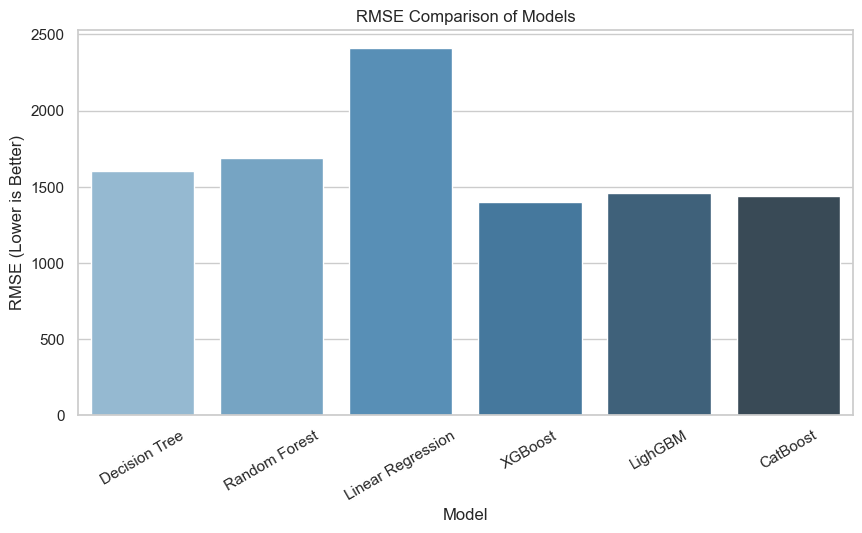

In [124]:
plt.figure(figsize=(10,5))
sns.barplot(x="model", y="rmse", data=models, palette="Blues_d")
plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE (Lower is Better)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.show()

### Training & Prediction Time Plot:

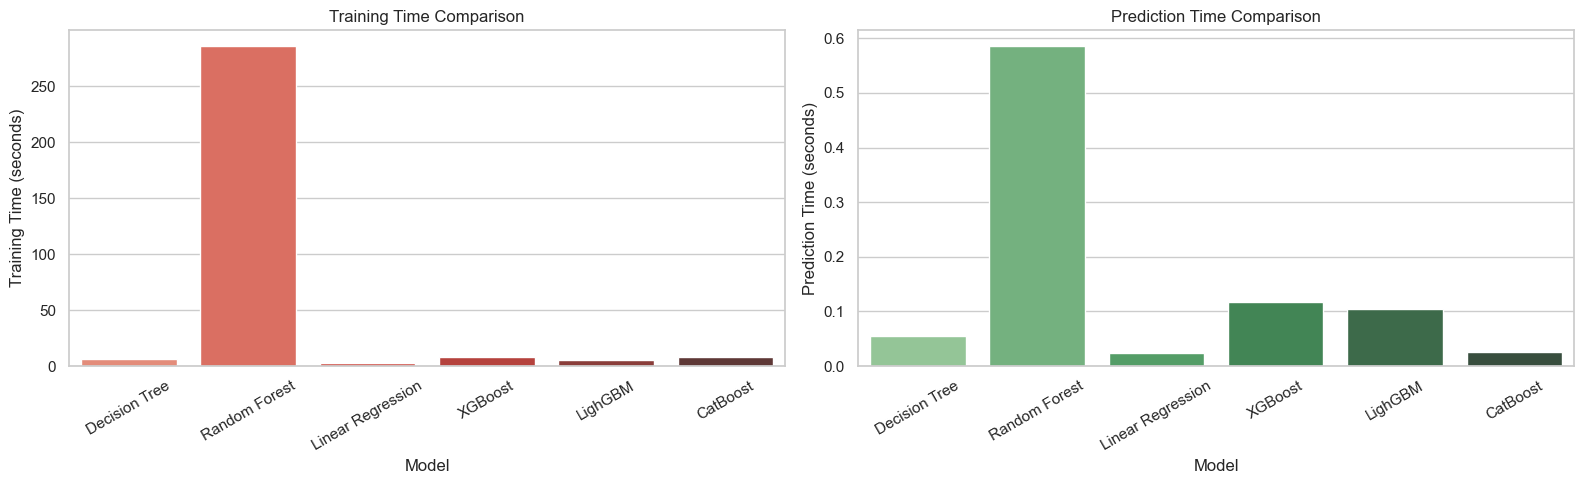

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training Time Plot:
sns.barplot(
    x="model",
    y="training_time",
    data=models,
    palette="Reds_d",
    ax=axes[0]
)
axes[0].set_title("Training Time Comparison")
axes[0].set_ylabel("Training Time (seconds)")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis='x', rotation=30)

# Prediction Time Plot:
sns.barplot(
    x="model",
    y="prediction_time",
    data=models,
    palette="Greens_d",
    ax=axes[1]
)
axes[1].set_title("Prediction Time Comparison")
axes[1].set_ylabel("Prediction Time (seconds)")
axes[1].set_xlabel("Model")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

<span style="font-size:16px;">

**- Final Recommendation:**
>Use `XGBoost` as the main model.
> `XGBoost` is both accurate and fast in prediction → Great for real-time use. <br>
`LightGBM` is a good balance if you want slightly faster training.
</span>

# Test Set

In [126]:
# Training model with optimal hyperparameters identified during validation.


# training time
start_train = time.perf_counter()
model_Xgb = XGBRegressor(random_state=34, n_estimators=500, max_depth=6, n_jobs=-1)
model_Xgb.fit(X_train, y_train)
training_time_test = time.perf_counter() - start_train

# prediction time
start_pred = time.perf_counter()
y_pred = model_Xgb.predict(X_test)
prediction_time_test = time.perf_counter() - start_pred

rmse_test = np.sqrt(
    mse(
        np.expm1(y_pred),
        np.expm1(y_test)
    )
)

print(f"""
- XGBoost - Test set Result:

RMSE:            {rmse_test:.3f}  
Training time:   {training_time_test:.2f}s  
Prediction time: {prediction_time_test:.2f}s
""")


- XGBoost - Test set Result:

RMSE:            1395.845  
Training time:   8.47s  
Prediction time: 0.15s



### Test Set Insights:
<span style="font-size:16px;">

**- RMSE** (1395.84) is very close to the validation result → model generalizes well and is **not overfitting**.

**- Training time** (8.47s) is relatively low → efficient model suitable for scaling.

**- Prediction time** (0.15s) is very fast → ideal for real-time or production use.

**- Overall,** the model achieves a strong balance between accuracy and efficiency.

### Next Step:

>Train and evaluate this model on **entire dataset** to utilize all available data.<br>
This will help confirm its robustness and observe final performance before deployment.
</span>

# Training Final Model on Full Dataset

In [127]:
#Split the Dataset into Train & Test set (80 / 20)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=12345)

In [128]:
print(f"Training set:   X={X_train.shape}, y={y_train.shape[0]}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape[0]}")

Training set:   X=(204900, 312), y=204900
Test set:       X=(51225, 312), y=51225


In [129]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

<span style="font-size:16px;">

> **Note:** Boosting models don't require feature scaling. However, scaling is applied here to ensure a fair comparison and as a sanity check for models like `Linear Regression` that are sensitive to feature scale.
</span>


In [130]:
#Final test on entire Dataset

# training time
start_train = time.perf_counter()
Xgb_final = XGBRegressor(random_state=34, n_estimators=500, max_depth=6, n_jobs=-1)
Xgb_final.fit(X_train, y_train)
training_time_final = time.perf_counter() - start_train

# prediction time
start_pred = time.perf_counter()
y_pred = Xgb_final.predict(X_test)
prediction_time_final = time.perf_counter() - start_pred

rmse_final = np.sqrt(
    mse(
        np.expm1(y_pred),
        np.expm1(y_test)
    )
)

print(f"""
- XGBoost - Full Dataset Result:

RMSE:            {rmse_final:.3f}  
Training time:   {training_time_final:.2f}s  
Prediction time: {prediction_time_final:.2f}s
""")


- XGBoost - Full Dataset Result:

RMSE:            1382.688  
Training time:   9.93s  
Prediction time: 0.15s



### Final Model Insights (Full Dataset):
<span style="font-size:16px;">

- **RMSE** (1382.69) remains consistent with validation and test results → confirms strong model stability and **no overfitting**.

- **Training time** (9.93s) is slightly improved → efficient even when using the full dataset.

- **Prediction time** (0.15s) is still very fast → suitable for real-time or production scenarios.

- **Overall performance** is stable across all stages → indicates a reliable and well-generalized model.

### Sanity Check:

>A sanity check is now performed using a simpler model (`Linear Regression`). <br>
This helps verify that the performance gain from `XGBoost` is meaningful and not due to data leakage or mistakes.

</span>

# Sanity Check

In [131]:
#Our baseline model (Linear Regression)

# training time
start_train = time.perf_counter()
lr = LinearRegression()
lr.fit(X_train, y_train)
training_time_baseline = time.perf_counter() - start_train

# prediction time
start_pred = time.perf_counter()
y_pred = lr.predict(X_test)
prediction_time_baseline = time.perf_counter() - start_pred

rmse_baseline = np.sqrt(
    mse(
        np.expm1(y_pred),
        np.expm1(y_test)
    )
)

print(f"""
- Linear Regression - (Baseline) Result:

RMSE:            {rmse_baseline:.2f}     
Training time:   {training_time_baseline:.2f}s  
Prediction time: {prediction_time_baseline:.2f}s
""")


- Linear Regression - (Baseline) Result:

RMSE:            2447.67     
Training time:   4.35s  
Prediction time: 0.04s



In [60]:
#RMSE improvement

rmse_improvement = (rmse_baseline - rmse_final) / rmse_baseline * 100

print(f"XGBoost improves RMSE by {rmse_improvement:.1f}% compared to Linear Regression.")

XGBoost improves RMSE by 43.5% compared to Linear Regression.


### Key Insights:
<span style="font-size:16px;">

- **Accuracy improvement:**
`XGBoost` RMSE (1382.69) vs `Linear Regression` RMSE (2447.67) → **43.5%** improvement in prediction error.
This is huge gain, showing `XGBoost` captures non-linear patterns much better.

- **Training time:**
`XGBoost` takes longer (10.09s vs 4.35s), but still reasonable for the full dataset.

- **Prediction time:**
Both models are fast (~0.15s) → `XGBoost` is production-friendly despite slightly longer training.

---
</span>

## Conclusion:
<span style="font-size:16px;">

**`XGBoost`** provides much better predictive performance while keeping prediction time low, making it a clear choice over **`Linear Regression`**.

</span>

# Summary
<span style="font-size:16px;">

> The goal of this project was to `develop a model` to determine the market value of a car based on historical data. The model needed to have `high accuracy` while maintaining `fast training` and `prediction times.`

**Steps Completed:**

- Descriptive Statistics
- Identified missing values, incorrect feature formats, and possible outliers.
- Noted categorical features and other data quality issues.

**Data Preprocessing:**

- Standardized column names
- Corrected data types
- Filled missing values
- Removed duplicates

**Exploratory Data Analysis (EDA):**

- Checked for outliers
- Created a new feature: `car_age`
- Dropped non-informative columns

**Encoding Categorical Variables:**

- Initially used `One-Hot Encoding` (OHE), which works well for linear models like `Linear Regression`.

**Data Splitting:**

- Split data into training, validation, and test sets to perform fair model selection.

**Model Selection and Hyperparameter Tuning:**

- Compared `Linear Regression`, `Decision Tree`, `Random Forest`, `XGBoost`, `LightGBM`, and `CatBoost`.
- Tuned hyperparameters for the best performance.
- Selected `XGBoost` based on a combination of RMSE, training time, and prediction speed.

**Retraining on Full Dataset:**

- Retrained the tuned `XGBoost` model on the entire dataset to leverage all available data.
- Test RMSE slightly improved, confirming better learning from more data.

**Sanity Check:**

- `Linear Regression` was used as a baseline.
- The baseline RMSE was **43.5%** higher than the `XGBoost` final model, demonstrating that our modeling process significantly improved prediction quality.

### ========================= Conclusion ===============================

**Final Model Performance** (`XGBoost`):

- **RMSE:** 1382.69
- **Training Time:** 9.93s
- **Prediction Time:** 0.15s
</span>